<a href="https://colab.research.google.com/github/anhthuktm2021-beep/Goi_y_thuc_don_dinh_duong/blob/main/notebooks/Giai_Doan_4_Truc_Quan_Hoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
import json
import matplotlib.pyplot as plt

# 1. Kết nối Drive
drive.mount('/content/drive')

# 2. Đọc Hồ sơ mục tiêu (Từ GĐ 2)
with open('/content/drive/MyDrive/Diet_Project/user_profile.json', 'r') as f:
    target = json.load(f)

# 3. Đọc Kết quả thực tế (Từ GĐ 3)
with open('/content/drive/MyDrive/Diet_Project/meal_results.json', 'r') as f:
    result = json.load(f)

print("Đã nạp đủ dữ liệu 'Mục tiêu' và 'Thực tế'. Bắt đầu vẽ biểu đồ thôi!")

Mounted at /content/drive
Đã nạp đủ dữ liệu 'Mục tiêu' và 'Thực tế'. Bắt đầu vẽ biểu đồ thôi!


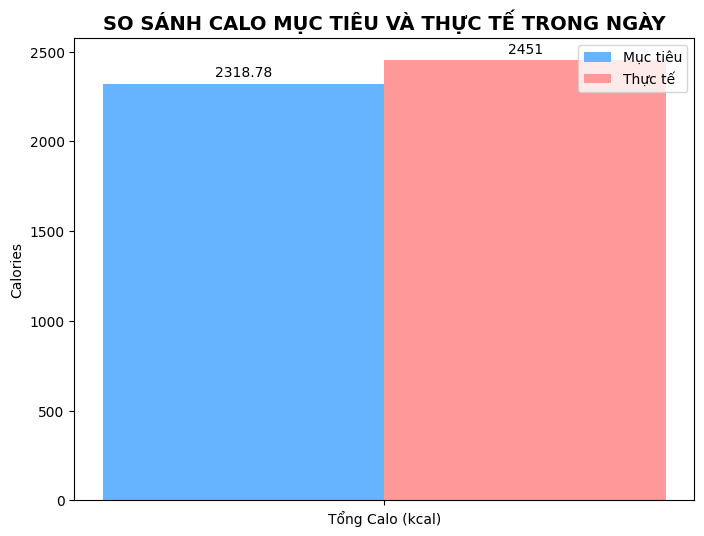

In [2]:
# Chuẩn bị dữ liệu cho biểu đồ cột
labels = ['Tổng Calo (kcal)']
muc_tieu = [target['tdee_target']]
thuc_te = [result['tong_calo_thuc_te']]

x = [1]  # Vị trí cột trên trục hoành
width = 0.35  # Độ rộng của cột

fig, ax = plt.subplots(figsize=(8, 6))

# Vẽ cột Mục tiêu và cột Thực tế nằm cạnh nhau
rects1 = ax.bar([i - width/2 for i in x], muc_tieu, width, label='Mục tiêu', color='#66b3ff')
rects2 = ax.bar([i + width/2 for i in x], thuc_te, width, label='Thực tế', color='#ff9999')

# Thêm tiêu đề và trang trí
ax.set_ylabel('Calories')
ax.set_title('SO SÁNH CALO MỤC TIÊU VÀ THỰC TẾ TRONG NGÀY', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Hiển thị số liệu trên đầu mỗi cột cho dễ nhìn
ax.bar_label(rects1, padding=3)
ax.bar_label(rects2, padding=3)

plt.show()

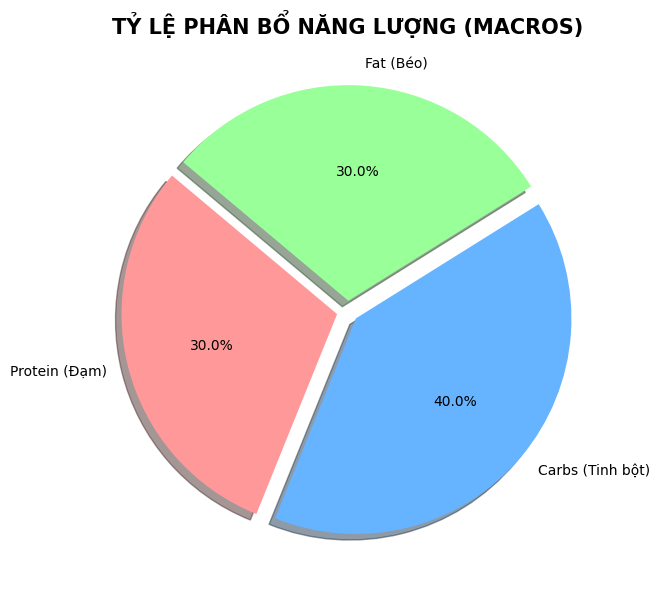

In [4]:
# 1. Trích xuất 3 thông số Macros từ file JSON mục tiêu
p_target = target['p_target']
c_target = target['c_target']
f_target = target['f_target']

# 2. Hàm vẽ biểu đồ tròn (Giữ nguyên logic cực xịn bạng đã có)
def ve_bieu_do_macros(p, c, f):
    labels = ['Protein (Đạm)', 'Carbs (Tinh bột)', 'Fat (Béo)']

    # Tính calo từ gram (Đạm x4, Tinh bột x4, Béo x9)
    sizes = [p * 4, c * 4, f * 9]
    colors = ['#ff9999', '#66b3ff', '#99ff99']
    explode = (0.05, 0.05, 0.05)

    plt.figure(figsize=(7, 7))
    plt.pie(sizes, explode=explode, labels=labels, colors=colors,
            autopct='%1.1f%%', shadow=True, startangle=140)

    plt.title('TỶ LỆ PHÂN BỔ NĂNG LƯỢNG (MACROS)', fontsize=15, fontweight='bold')
    plt.show()

# 3. Chạy hàm để hiển thị bánh donut
ve_bieu_do_macros(p_target, c_target, f_target)